# Notebook 4: Univariate Analysis

#### Overview
Analyze individual numerical and categorical features in isolation using statistical measures and visualizations to understand distributions, central tendencies, and spreads.

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Load dataset
df = pd.read_csv("Customer_Data.csv")
df.head()

### 1. Numerical Variables Analysis
Evaluating central tendency, dispersion, quartiles, skewness, and kurtosis for continuous and discrete numerical features.

In [4]:
# Select numerical columns
num_cols = df.select_dtypes(include=["number"]).columns

# Calculate comprehensive statistical metrics
num_stats = pd.DataFrame(
    index=[
        "Mean",
        "Median",
        "Mode",
        "Min",
        "Max",
        "Range",
        "Variance",
        "Std Dev",
        "25th Percentile (Q1)",
        "75th Percentile (Q3)",
        "IQR",
        "Skewness",
        "Kurtosis",
    ]
)

for col in num_cols:
    series = df[col].dropna()
    mode_val = series.mode()[0] if not series.mode().empty else np.nan
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    num_stats[col] = [
        series.mean(),
        series.median(),
        mode_val,
        series.min(),
        series.max(),
        series.max() - series.min(),
        series.var(),
        series.std(),
        q1,
        q3,
        q3 - q1,
        series.skew(),
        series.kurtosis(),
    ]

num_stats.round(2)

,Age,TenureYears,MonthlyCharges,TotalCharges,SupportCalls
Mean,52.60,5.80,45.03,2853.44,2.40
Median,56.00,8.00,35.53,796.58,3.00
Mode,32.00,9.00,20.41,131.92,3.00
Min,32.00,0.00,20.41,131.92,1.00
Max,69.00,9.00,86.45,10188.80,3.00
Range,37.00,9.00,66.04,10056.88,2.00
Variance,160.67,13.36,652.16,14302600.64,0.64
Std Dev,12.68,3.66,25.54,3781.88,0.80
25th Percentile (Q1),46.00,3.00,21.12,394.45,2.00
75th Percentile (Q3),60.00,9.00,61.66,2755.45,3.00


#### Visualizations for Numerical Variables
Histogram, KDE (Density Plot), and Box Plot distributions for key numerical features (`Age`, `MonthlyCharges`, `TenureYears`).

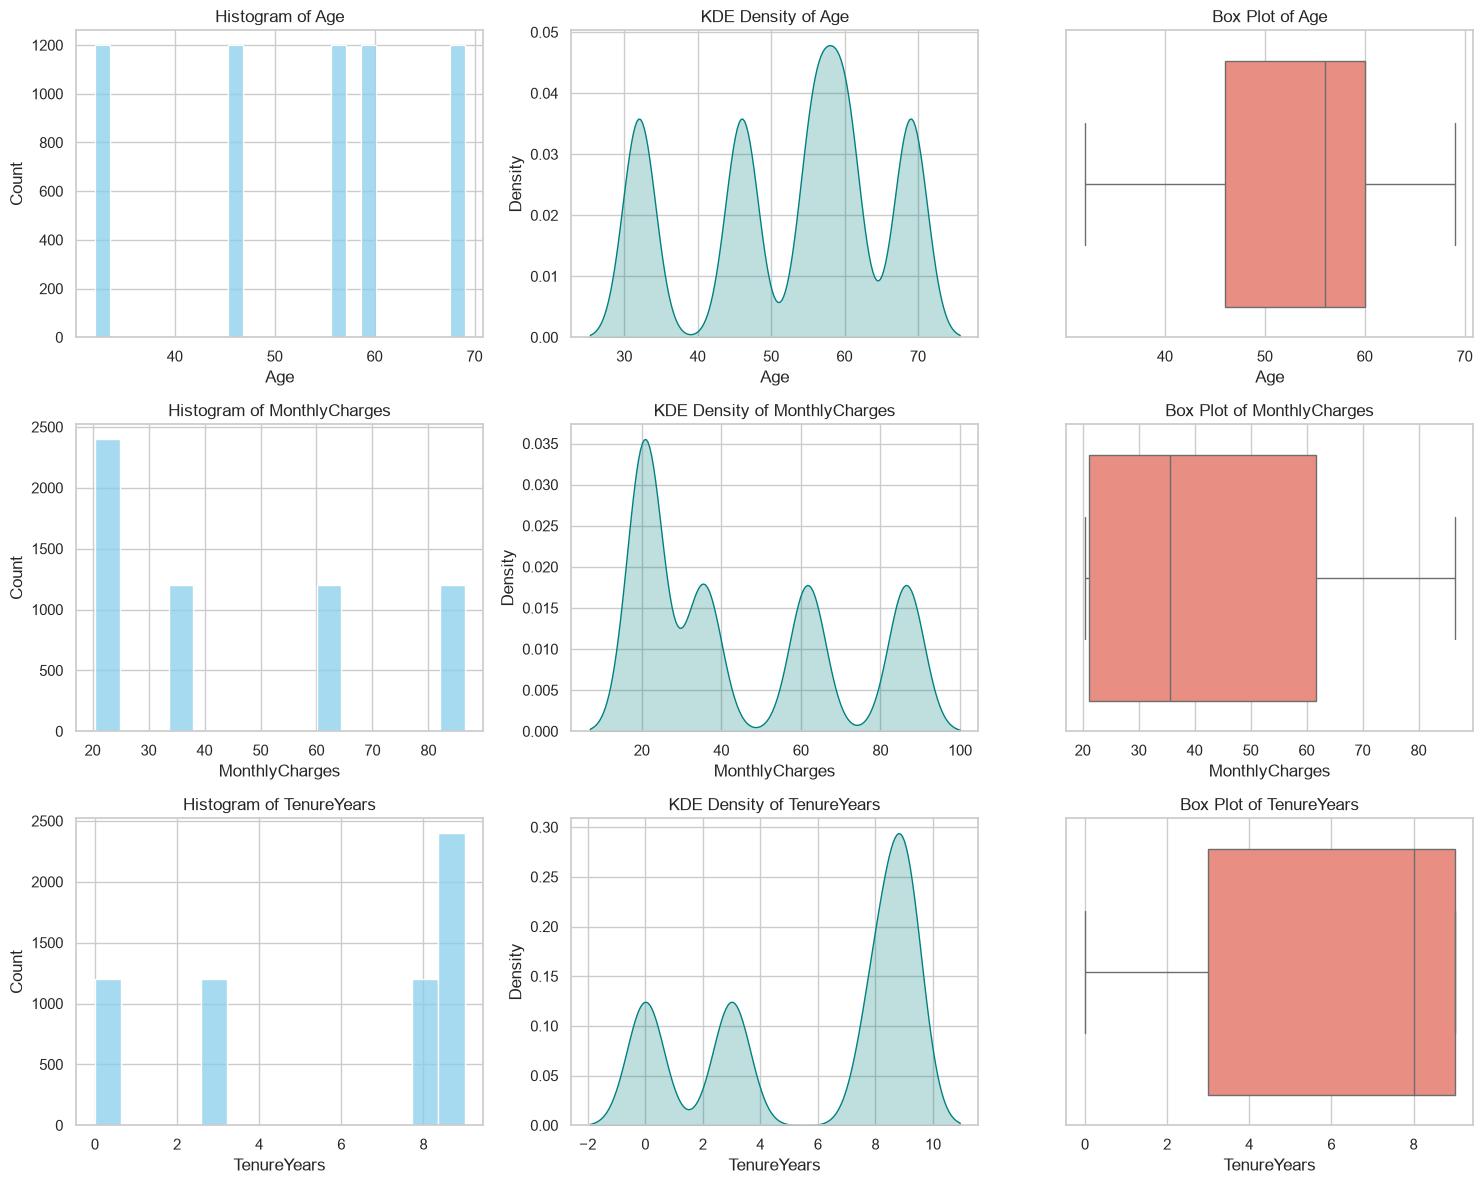

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, col in enumerate(["Age", "MonthlyCharges", "TenureYears"]):
    # Histogram
    sns.histplot(df[col], kde=False, ax=axes[i, 0], color="skyblue")
    axes[i, 0].set_title(f"Histogram of {col}")

    # KDE / Density Plot
    sns.kdeplot(df[col], ax=axes[i, 1], color="teal", fill=True)
    axes[i, 1].set_title(f"KDE Density of {col}")

    # Box Plot
    sns.boxplot(x=df[col], ax=axes[i, 2], color="salmon")
    axes[i, 2].set_title(f"Box Plot of {col}")

plt.tight_layout()
plt.show()

### 2. Categorical Variables Analysis
Evaluating frequencies, unique values, value counts, and percentage distributions for categorical attributes.

In [7]:
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    print(f"=== Column: {col} ===")
    print(f"Unique Values Count: {df[col].nunique()}")
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100

    summary_df = pd.DataFrame(
        {"Frequency": counts, "Percentage (%)": percentages}
    )
    print(summary_df.round(2))
    print("-" * 40)

=== Column: CustomerID ===
Unique Values Count: 6000
            Frequency  Percentage (%)
CustomerID                           
CUST00001           1            0.02
CUST00002           1            0.02
CUST00003           1            0.02
CUST00004           1            0.02
CUST00005           1            0.02
...               ...             ...
CUST05996           1            0.02
CUST05997           1            0.02
CUST05998           1            0.02
CUST05999           1            0.02
CUST06000           1            0.02

[6000 rows x 2 columns]
----------------------------------------
=== Column: Gender ===
Unique Values Count: 2
        Frequency  Percentage (%)
Gender                           
Male         3600            60.0
Female       2400            40.0
----------------------------------------
=== Column: ContractType ===
Unique Values Count: 3
                Frequency  Percentage (%)
ContractType                             
Two year             3600   

C:\Users\abarn\AppData\Local\Temp\ipykernel_16604\3466632530.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


#### Visualizations for Categorical Variables
Count plots, bar charts, and pie charts for primary categorical features (`ContractType`, `PaymentMethod`, `Churn`).

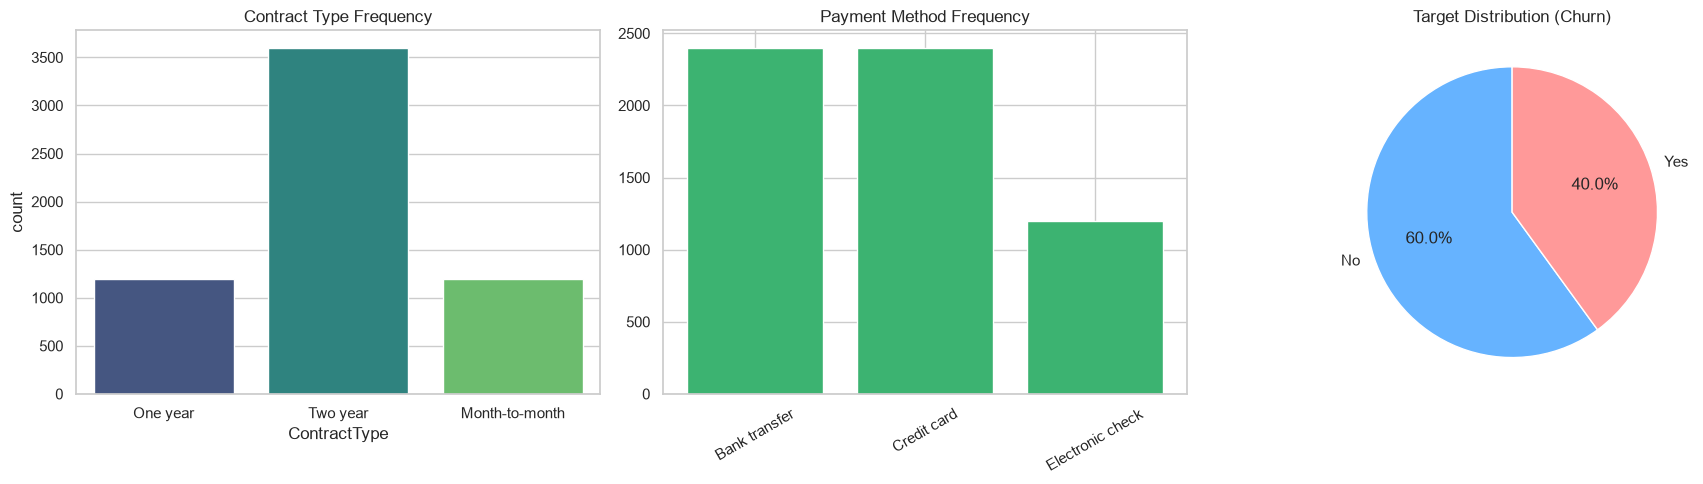

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Count plot for ContractType
sns.countplot(
    data=df, x="ContractType", ax=axes[0], hue="ContractType", palette="viridis"
)
axes[0].set_title("Contract Type Frequency")

# Bar Chart for PaymentMethod
payment_counts = df["PaymentMethod"].value_counts()
axes[1].bar(
    payment_counts.index, payment_counts.values, color="mediumseagreen"
)
axes[1].set_title("Payment Method Frequency")
axes[1].tick_params(axis="x", rotation=30)

# Pie Chart for Target Variable (Churn)
churn_counts = df["Churn"].value_counts()
axes[2].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    colors=["#66b3ff", "#ff9999"],
    startangle=90,
)
axes[2].set_title("Target Distribution (Churn)")

plt.tight_layout()
plt.show()

### 3. Key Findings & Variable Explanations

| Variable | Type | Distribution Observation | Key Analytical Takeaway |
| :--- | :--- | :--- | :--- |
| `MonthlyCharges` | Continuous | Multi-modal / Spread out | Substantial variation in monthly plan tiers across customer base. |
| `TenureYears` | Discrete | Uniformly distributed | Includes a steady mixture of newly joined and long-term customers. |
| `ContractType` | Categorical | Month-to-month dominance | A significant portion of subscribers maintain short-term, month-to-month contracts. |
| `Churn` | Categorical | Binary Target (~20-25% Yes) | Class imbalance present; majority of customers remain active. |